In [43]:
#!pip install segmentation_models_pytorch

In [75]:
import torch
import scipy
import cv2
import os
import time
import albumentations
import numpy                        as np # linear algebra
import pandas                       as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot            as plt
import segmentation_models_pytorch  as smp
import torch.nn.functional          as F
import torch.nn                     as nn
# Barra de progreso compatible con Jupyter aunque ipywidgets/IProgress no esté instalado
from tqdm               import tqdm
from PIL                import Image
from torchvision        import transforms as T
from torch.utils.data   import Dataset, DataLoader  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [45]:
try:
    KAGGLE_API_TOKEN = os.environ['KAGGLE_API_TOKEN']
except KeyError:
    raise KeyError("KAGGLE_API_TOKEN not found in environment variables. Please set it in your .env file or export it in your shell.")

In [46]:
import kagglehub

# Descarga (o reutiliza si ya está en caché local) el dataset de la competencia.
# kagglehub se encarga de la autenticación: si no tienes credenciales configuradas,
# te va a pedir tu Kaggle username y un API token (Settings > API > Create New Token en kaggle.com).
# Los archivos quedan cacheados en disco, así que si vuelves a correr esta celda no se re-descargan.
DATA_DIR = kagglehub.competition_download('covid-segmentation')
print("Path to competition files:", DATA_DIR)

for dirname, _, filenames in os.walk(DATA_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Path to competition files: /Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/images_radiopedia.npy
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/images_medseg.npy
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/test_images_medseg.npy
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/masks_radiopedia.npy
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/masks_medseg.npy


In [47]:
prefix = DATA_DIR
    
images_radiopedia   = np.load(os.path.join(prefix, 'images_radiopedia.npy')).astype(np.float32)
masks_radiopedia    = np.load(os.path.join(prefix, 'masks_radiopedia.npy')).astype(np.int8)
images_medseg       = np.load(os.path.join(prefix, 'images_medseg.npy')).astype(np.float32)
masks_medseg        = np.load(os.path.join(prefix, 'masks_medseg.npy')).astype(np.int8)
test_images_medseg  = np.load(os.path.join(prefix, 'test_images_medseg.npy')).astype(np.float32)

In [48]:
print(images_radiopedia.min(), images_radiopedia.max())

-1414.7654 291.04077


In [49]:
def visualize(image_batch, mask_batch=None, pred_batch=None, num_samples=8, hot_encode=True):
    num_classes = mask_batch.shape[-1] if mask_batch is not None else 0
    _, ax       = plt.subplots(num_classes + 1, num_samples, figsize=(num_samples * 2, (num_classes + 1) * 2))

    for i in range(num_samples):
        ax_image = ax[0, i] if num_classes > 0 else ax[i]
        if hot_encode: 
            ax_image.imshow(image_batch[i,:,:,0], cmap='Greys')
        else: 
            ax_image.imshow(image_batch[i,:,:])
        ax_image.set_xticks([]) 
        ax_image.set_yticks([])
        
        if mask_batch is not None:
            for j in range(num_classes):
                if pred_batch is None:
                    mask_to_show = mask_batch[i,:,:,j]
                else:
                    mask_to_show = np.zeros(shape=(*mask_batch.shape[1:-1], 3)) 
                    mask_to_show[..., 0] = pred_batch[i,:,:,j] > 0.5
                    mask_to_show[..., 1] = mask_batch[i,:,:,j]
                ax[j + 1, i].imshow(mask_to_show, vmin=0, vmax=1)
                ax[j + 1, i].set_xticks([]) 
                ax[j + 1, i].set_yticks([]) 

    plt.tight_layout()
    plt.show()

In [50]:
def onehot_to_mask(mask, palette):
    """
    Converts a mask (H, W, K) to (H, W, C)
    """
    x = np.argmax(mask, axis=-1)
    colour_codes = np.array(palette)
    x = np.uint8(colour_codes[x.astype(np.uint8)])
    return x

In [51]:
def preprocess_images(images_arr, mean_std=None):
    # Clipping
    images_arr[images_arr > 500]    = 500
    images_arr[images_arr < -1500]  = -1500
    # Robust scaling
    min_perc, max_perc  = np.percentile(images_arr, 5), np.percentile(images_arr, 95)
    images_arr_valid    = images_arr[(images_arr > min_perc) & (images_arr < max_perc)]
    # Standarization
    mean, std           = (images_arr_valid.mean(), images_arr_valid.std()) if mean_std is None else mean_std
    images_arr          = (images_arr - mean) / std
    print(f'mean {mean}, std {std}')
    return images_arr, (mean, std)

In [52]:
def plot_hists(images1, images2=None):
    plt.hist(images1.ravel(), bins=100, density=True, color='b', alpha=1 if images2 is None else 0.5)
    if images2 is not None:
        plt.hist(images2.ravel(), bins=100, density=True, alpha=0.5, color='orange')
    plt.show()

In [53]:

def pixel_accuracy(output, mask):
    with torch.no_grad():
        output = torch.argmax(F.softmax(output, dim=1), dim=1)
        correct = torch.eq(output, mask).int()
        accuracy = float(correct.sum()) / float(correct.numel())
    return accuracy


In [54]:
def mIoU(pred_mask, mask, smooth=1e-10, n_classes=4):
    with torch.no_grad():
        pred_mask = F.softmax(pred_mask, dim=1)
        pred_mask = torch.argmax(pred_mask, dim=1)
        pred_mask = pred_mask.contiguous().view(-1)
        mask = mask.contiguous().view(-1)

        iou_per_class = []
        for clas in range(0, n_classes): #loop per pixel class
            true_class = pred_mask == clas
            true_label = mask == clas

            if true_label.long().sum().item() == 0: #no exist label in this loop
                iou_per_class.append(np.nan)
            else:
                intersect = torch.logical_and(true_class, true_label).sum().float().item()
                union = torch.logical_or(true_class, true_label).sum().float().item()

                iou = (intersect + smooth) / (union +smooth)
                iou_per_class.append(iou)
        return np.nanmean(iou_per_class)

In [55]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def fit(epochs, model, train_loader, val_loader, criterion, optimizer, scheduler, patch=False):
    train_losses,val_iou,val_acc,lrs = [],[],[],[]
    test_losses,train_iou,train_acc  = [],[],[]
    min_loss    = np.inf
    decrease    = 1
    not_improve = 0

    model.to(device)
    fit_time = time.time()
    for e in range(epochs):
        since        = time.time()
        running_loss = 0
        iou_score    = 0
        accuracy     = 0
        #training loop
        model.train()
        for _, data in enumerate(tqdm(train_loader)):
            #training phase
            image_tiles, mask_tiles = data
            image = image_tiles.to(device)
            mask  = mask_tiles.to(device)
            #forward
            output = model(image)
            
            loss = criterion(output, mask)
            #evaluation metrics
            iou_score += mIoU(output, mask)
            accuracy  += pixel_accuracy(output, mask)
            #backward
            loss.backward()
            optimizer.step() #update weight          
            optimizer.zero_grad() #reset gradient
            
            #step the learning rate
            lrs.append(get_lr(optimizer))
            scheduler.step()
            
            running_loss += loss.item()
            

        else:
            model.eval()
            test_loss     = 0
            test_accuracy = 0
            val_iou_score = 0
            #validation loop
            with torch.no_grad():
                for _, data in enumerate(tqdm(val_loader)):
                    image_tiles, mask_tiles = data

                    image = image_tiles.to(device); mask =mask_tiles.to(device);
                    output = model(image)
                    #evaluation metrics
                    val_iou_score +=  mIoU(output, mask)
                    test_accuracy += pixel_accuracy(output, mask)
                    #loss
                    loss = criterion(output, mask)                                  
                    test_loss += loss.item()
            
            #calculatio mean for each batch
            train_losses.append(running_loss/len(train_loader))
            test_losses.append(test_loss/len(val_loader))


            if min_loss > (test_loss/len(val_loader)):
                print('Loss Decreasing.. {:.3f} >> {:.3f} '.format(min_loss, (test_loss/len(val_loader))))
                min_loss = (test_loss/len(val_loader))
                decrease += 1
                if decrease % 5 == 0:
                    print('saving model...')
                    torch.save(model, 'Unet_efficientnet_b2_mIoU-{:.3f}.pt'.format(val_iou_score/len(val_loader)))
                    

            if (test_loss/len(val_loader)) > min_loss:
                not_improve += 1
                min_loss = (test_loss/len(val_loader))
                print(f'Loss Not Decrease for {not_improve} time')
                if not_improve == 7:
                    print('Loss not decrease for 7 times, Stop Training')
                    break
            
            #iou
            val_iou.append(val_iou_score/len(val_loader))
            train_iou.append(iou_score/len(train_loader))
            train_acc.append(accuracy/len(train_loader))
            val_acc.append(test_accuracy/ len(val_loader))
            print("Epoch:{}/{}..".format(e+1, epochs),
                  "Train Loss: {:.3f}..".format(running_loss/len(train_loader)),
                  "Val Loss: {:.3f}..".format(test_loss/len(val_loader)),
                  "Train mIoU:{:.3f}..".format(iou_score/len(train_loader)),
                  "Val mIoU: {:.3f}..".format(val_iou_score/len(val_loader)),
                  "Train Acc:{:.3f}..".format(accuracy/len(train_loader)),
                  "Val Acc:{:.3f}..".format(test_accuracy/len(val_loader)),
                  "Time: {:.2f}m".format((time.time()-since)/60))
        
    history = {'train_loss' : train_losses, 'val_loss': test_losses,
               'train_miou' :train_iou, 'val_miou':val_iou,
               'train_acc' :train_acc, 'val_acc':val_acc,
               'lrs': lrs}
    print('Total time: {:.2f} m' .format((time.time()- fit_time)/60))
    return history

In [56]:
def plot_loss(history):
    plt.plot(history['val_loss'], label='val', marker='o')
    plt.plot( history['train_loss'], label='train', marker='o')
    plt.title('Loss per epoch'); plt.ylabel('loss');
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()
    
def plot_score(history):
    plt.plot(history['train_miou'], label='train_mIoU', marker='*')
    plt.plot(history['val_miou'], label='val_mIoU',  marker='*')
    plt.title('Score per epoch'); plt.ylabel('mean IoU')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()
    
def plot_acc(history):
    plt.plot(history['train_acc'], label='train_accuracy', marker='*')
    plt.plot(history['val_acc'], label='val_accuracy',  marker='*')
    plt.title('Accuracy per epoch'); plt.ylabel('Accuracy')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

In [57]:
def predict_image_mask_miou(model, image, mask, mean=[0.485], std=[0.229]):
    model.eval()
    model.to(device)
    image = image.to(device)
    mask  = mask.to(device)

    with torch.no_grad():
        output = model(image)
        score  = mIoU(output, mask)
        masked = torch.argmax(output, dim=1)
        masked = masked.cpu().squeeze(0)
    return masked, score, output.permute(0, 2, 3,1)

In [58]:
def test_predict(model, image, mean=[0.485], std=[0.229]):
    t     = T.Compose([T.ToTensor(), T.Normalize(mean, std)])
    image = t(image)
    model.eval()
    
    model.to(device)
    image = image.to(device)
    
    with torch.no_grad():
        output = model(torch.unsqueeze(image,1))
        output = nn.Softmax(dim=1)(output)
    return output.permute(0, 2, 3,1)

In [59]:
def predict_image_mask_pixel(model, image, mask, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    model.eval()
    model.to(device); image=image.to(device)
    mask = mask.to(device)
    with torch.no_grad():
        output = model(image)
        acc    = pixel_accuracy(output, mask)
        masked = torch.argmax(output, dim=1)
        masked = masked.cpu().squeeze(0)
        
    return masked, acc

In [60]:
def mask_to_onehot(mask, palette):
    """
    Converts a segmentation mask (H, W, C) to (H, W, K) where the last dim is a one
    hot encoding vector, C is usually 1 or 3, and K is the number of class.
    """
    semantic_map = []
    for colour in palette:
        equality  = np.equal(mask, colour)
        class_map = np.all(equality, axis=-1)
        semantic_map.append(class_map)
    semantic_map = np.stack(semantic_map, axis=-1).astype(np.float32)
    return torch.from_numpy(semantic_map)

In [61]:
def miou_score(model, test_set):
    score_iou = []
    for _, data in enumerate(tqdm(test_set)):
        img, mask = data
        _, score,_ = predict_image_mask_miou(model, img, mask)
        score_iou.append(score)
    return score_iou

In [62]:
class Dataset:   
    def __init__(self, images, masks,augmentations=None):
        self.images = images
        self.masks = masks
        self.augmentations = augmentations
        self.mean = [0.485]
        self.std = [0.229]
    
    def __getitem__(self, i):
        image = self.images[i]
        mask = self.masks[i]
        
        if self.augmentations is not None:
            sample = self.augmentations(image=image, mask=mask)
            
            image, mask = Image.fromarray(np.squeeze(sample['image'], axis=2)), sample['mask']
        
        if self.augmentations is None:
            image = Image.fromarray(image)
        
        t = T.Compose([T.ToTensor(), T.Normalize(self.mean, self.std)])
        image = t(image)
        mask = torch.from_numpy(mask).long()
    
        return image, mask
    
    def __len__(self):
        return len(self.images)
    
    def tiles(self, image, mask):
        img_patches = image.unfold(1, 512, 512).unfold(2, 768, 768) 
        img_patches  = img_patches.contiguous().view(3,-1, 512, 768) 
        img_patches = img_patches.permute(1,0,2,3)
        
        mask_patches = mask.unfold(0, 512, 512).unfold(1, 768, 768)
        mask_patches = mask_patches.contiguous().view(-1, 512, 768)
        
        return img_patches, mask_patches

### Images from radiopedia are full CT volumes:
Class 0 is "ground glass"<br>
Class 1 is "consolidations"<br>
Class 2 is "lungs other" – it doesn't mean that it is healthy lungs (you don't need to predict this class)<br>
Class 3 is "background" – not lungs (you don't need to predict this class)<br>

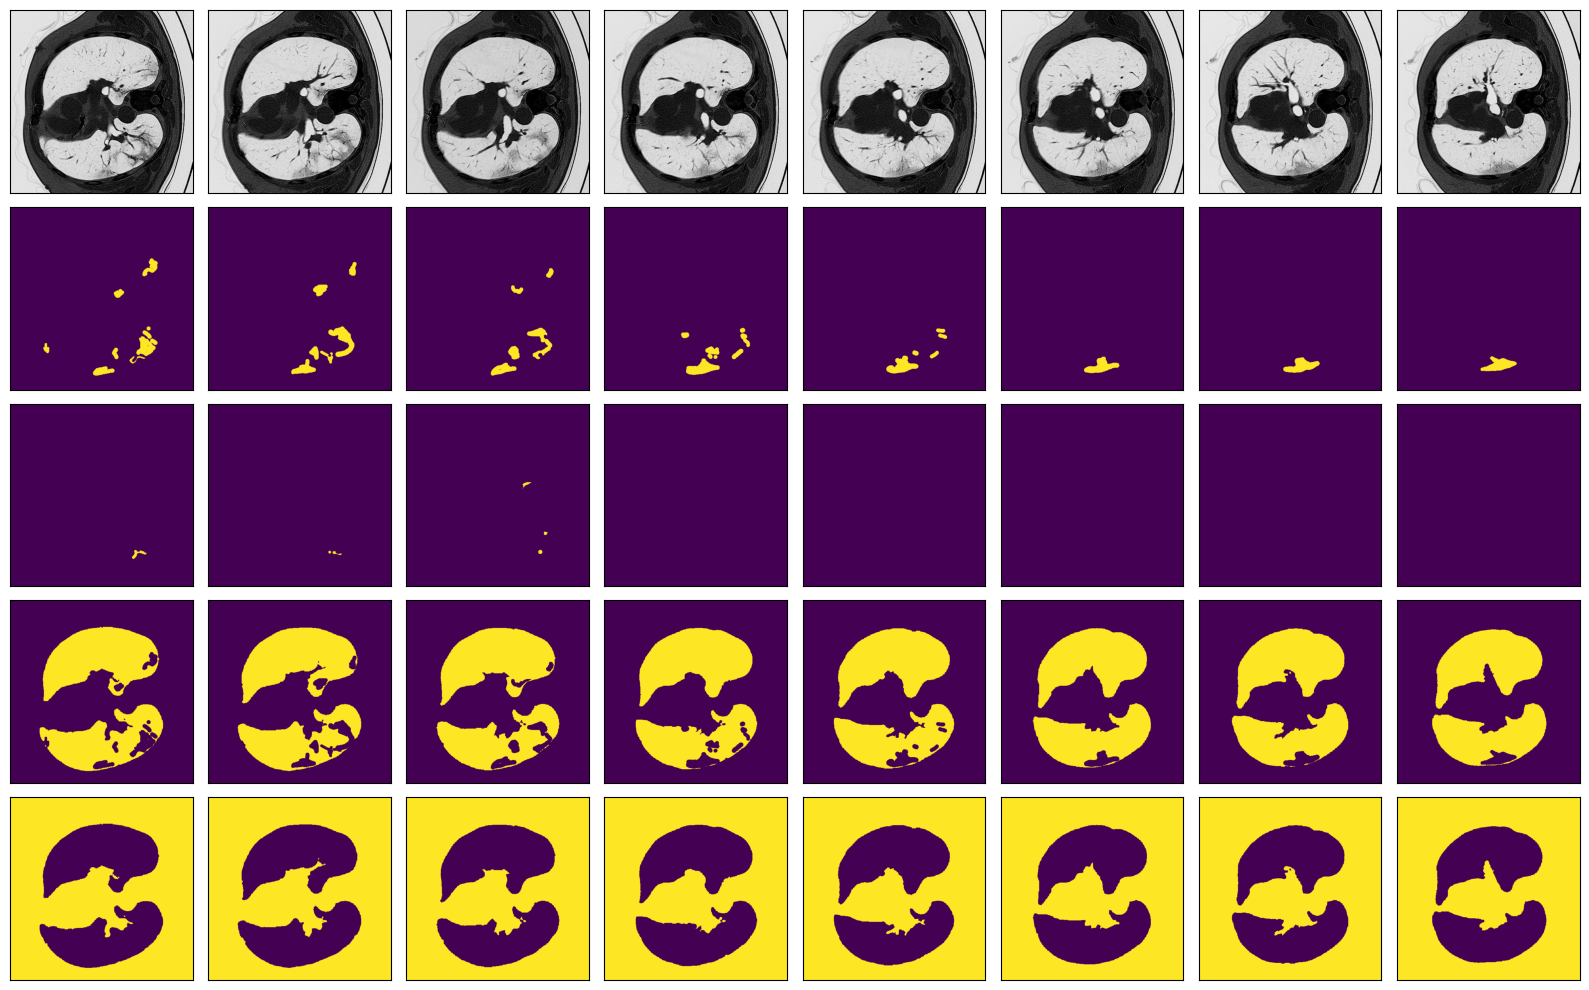

In [63]:
visualize(images_radiopedia[30:], masks_radiopedia[30:])

Hot encoded mask size:  (829, 512, 512, 4)
Paletted mask size: (100, 512, 512)


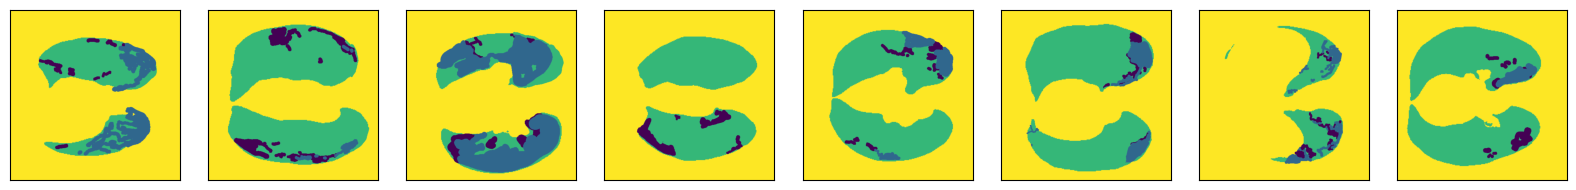

In [64]:
palette = [[0], [1], [2],[3]]
masks_radiopedia_recover = onehot_to_mask(masks_radiopedia, palette).squeeze()  # shape = (H, W)

masks_medseg_recover = onehot_to_mask(masks_medseg, palette).squeeze()  # shape = (H, W)

print('Hot encoded mask size: ',masks_radiopedia.shape)
print('Paletted mask size:',masks_medseg_recover.shape)

visualize(masks_medseg_recover[30:],hot_encode=False)

## Preprocess images:

In [65]:
images_radiopedia, mean_std = preprocess_images(images_radiopedia)
images_medseg, _ = preprocess_images(images_medseg, mean_std)
test_images_medseg, _ = preprocess_images(test_images_medseg, mean_std)

mean -451.6488342285156, std 458.56787109375
mean -451.6488342285156, std 458.56787109375
mean -451.6488342285156, std 458.56787109375


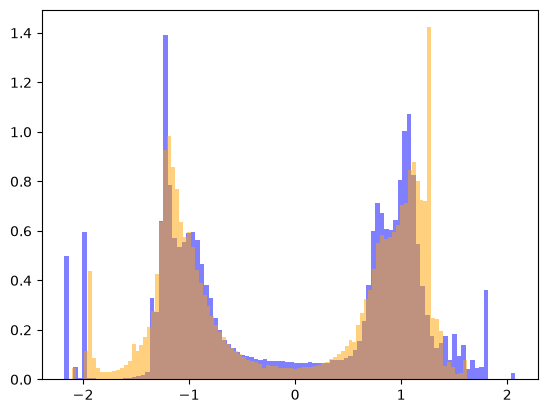

In [66]:
plot_hists(test_images_medseg, images_radiopedia)

## Split/Train

In [67]:
masks_radiopedia_recover = onehot_to_mask(masks_radiopedia, palette).squeeze()  # shape = (H, W)
masks_medseg_recover     = onehot_to_mask(masks_medseg, palette).squeeze()  # shape = (H, W)

val_indexes, train_indexes = list(range(24)), list(range(24, 100))

train_images = np.concatenate((images_medseg[train_indexes], images_radiopedia))
train_masks  = np.concatenate((masks_medseg_recover[train_indexes], masks_radiopedia_recover))
val_images   = images_medseg[val_indexes]
val_masks    = masks_medseg_recover[val_indexes]

batch_size = len(val_masks)

del masks_medseg_recover
del masks_radiopedia_recover
del images_radiopedia
del masks_radiopedia
del images_medseg
del masks_medseg

## Data generator and augmentations

In [68]:
SOURCE_SIZE = 512
TARGET_SIZE = 256

train_augs = albumentations.Compose([
    albumentations.Rotate(limit=360, p=0.9, border_mode=cv2.BORDER_REPLICATE),
    albumentations.RandomSizedCrop((int(SOURCE_SIZE * 0.75), SOURCE_SIZE), 
                                   (TARGET_SIZE, TARGET_SIZE), 
                                   interpolation=cv2.INTER_NEAREST),
    albumentations.HorizontalFlip(p=0.5),

])

val_augs = albumentations.Compose([
    albumentations.Resize(TARGET_SIZE, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)
])

In [69]:
train_dataset    = Dataset(train_images, train_masks, train_augs)
val_dataset      = Dataset(val_images, val_masks, val_augs)       
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

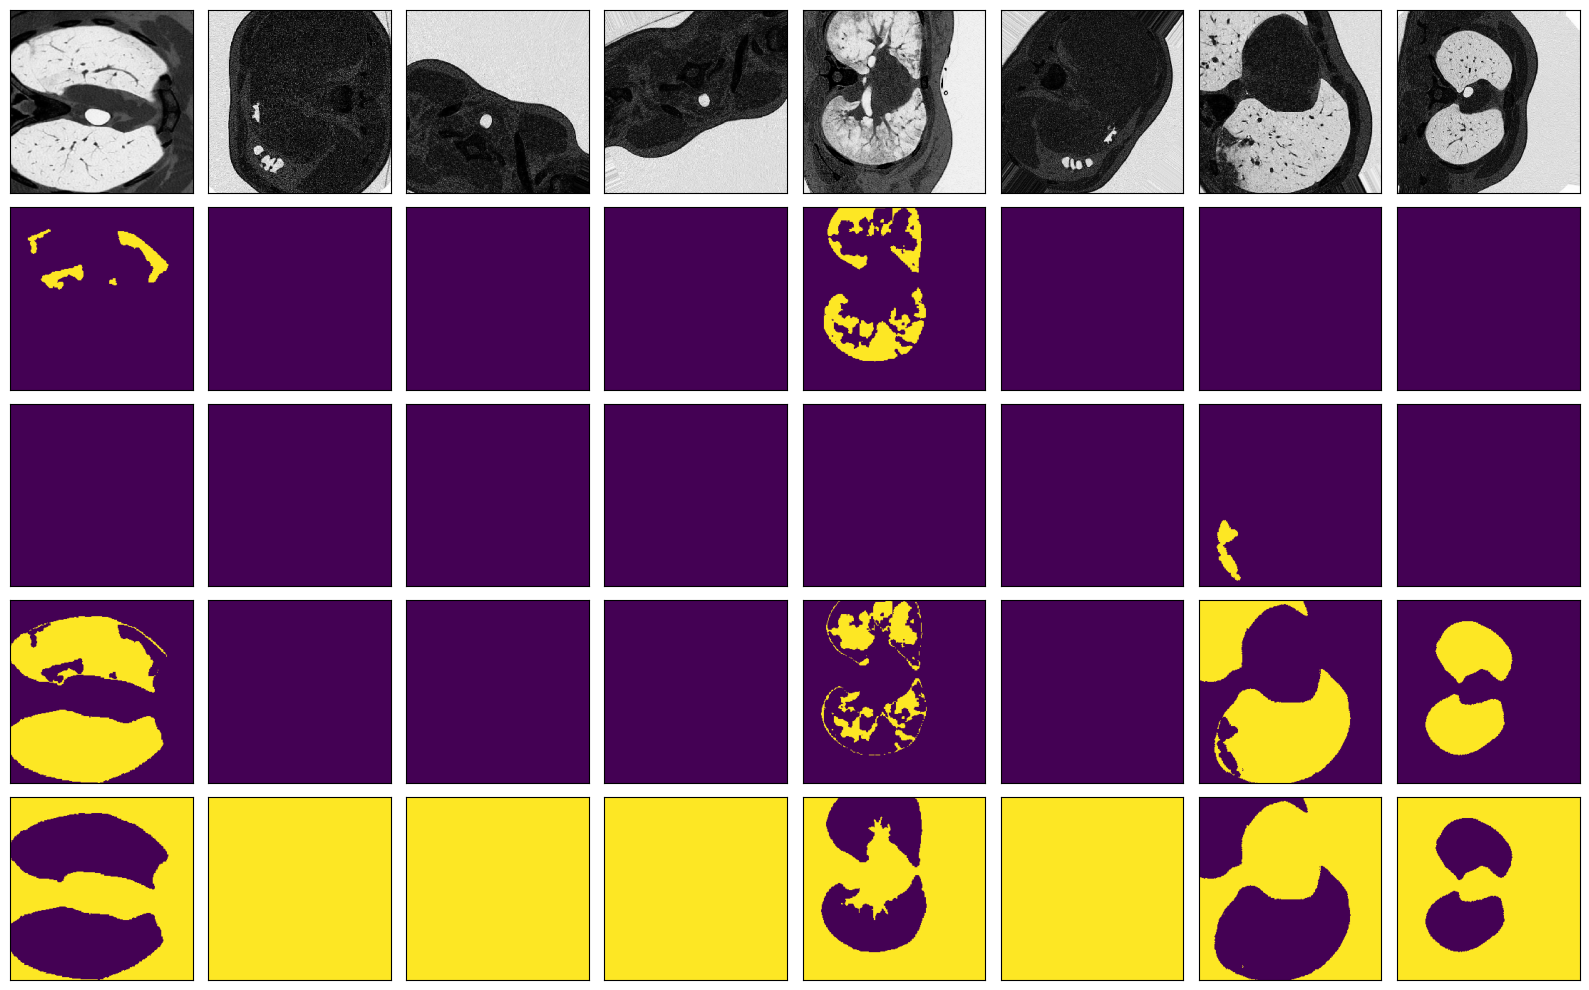

In [72]:
i,train_data     = next(enumerate(train_dataloader))
mask_hot_encoded = mask_to_onehot(torch.unsqueeze(train_data[1],-1).numpy(),palette)
visualize(train_data[0].permute(0, 2, 3,1),mask_hot_encoded)

In [76]:
max_lr       = 1e-2
epoch        = 10
weight_decay = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
sched     = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epoch,
                                            steps_per_epoch=len(train_dataloader))

history = fit(epoch, model, train_dataloader, val_dataloader, criterion, optimizer, sched)



























 66%|██████▌   | 25/38 [05:17<02:45, 12.70s/it]
Exception ignored in: <function tqdm.__del__ at 0x10eae5080>
Traceback (most recent call last):
  File "/Users/manuelbajos/Documents/tec/semestres/Septimo/ConcentracionIA/reto/Covid/COVID-19-CT/venv/lib/python3.13/site-packages/tqdm/std.py", line 1154, in __del__
    self.close()
  File "/Users/manuelbajos/Documents/tec/semestres/Septimo/ConcentracionIA/reto/Covid/COVID-19-CT/venv/lib/python3.13/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x10eae5080>
Traceback (most recent call last):
  File "/Users/manuelbajos/Documents/tec/semestres/Septimo/ConcentracionIA/reto/Covid/COVID-19-CT/venv/lib/python3.13/site-packages/tqdm/std.py", line 1154, in __del__
    self.close()
  File "/Users/manuelbajos/Documents/tec/semestres/Septimo/ConcentracionIA/ret

KeyboardInterrupt: 

In [74]:
model = smp.Unet('efficientnet-b2',in_channels=1, encoder_weights='imagenet',classes=4, activation=None, encoder_depth=5, decoder_channels=[256, 128, 64, 32, 16])

In [ ]:
torch.save(model, 'Unet-efficientnet.pt')

In [ ]:
plot_loss(history)
plot_score(history)
plot_acc(history)

## Evaluation

### Result

In [ ]:
image, mask             = next(iter(val_dataloader))
pred_mask, score,output = predict_image_mask_miou(model, image, mask)
semantic_map            = mask_to_onehot(torch.unsqueeze(mask,-1).numpy(),palette)

In [ ]:
visualize(image.cpu(), semantic_map, pred_batch=output.cpu())

In [ ]:
mob_miou = miou_score(model, val_dataloader)
mob_miou

In [ ]:
del train_images
del train_masks

## Test preds:

In [ ]:
image_batch = np.stack([val_augs(image=img)['image'] for img in test_images_medseg], axis=0)
print(torch.from_numpy(image_batch).shape)
print(image_batch[i].shape)
#output = test_predict(model, torch.from_numpy(image_batch).permute(0, 3, 1,2))
output = np.zeros((10,256,256,4))
for i in range(10):   
    output[i] = test_predict(model, image_batch[i]).cpu().numpy()
print(output.shape)
test_masks_prediction = output > 0.5
visualize(image_batch, test_masks_prediction, num_samples=len(test_images_medseg))

## Resize prediction to original size 

In [ ]:
test_masks_prediction_original_size = scipy.ndimage.zoom(test_masks_prediction[..., :-2], (1, 2, 2, 1), order=0)
test_masks_prediction_original_size.shape

In [ ]:
pd.DataFrame(
             data=np.stack((np.arange(len(test_masks_prediction_original_size.ravel())), 
                            test_masks_prediction_original_size.ravel().astype(int)),
                            axis=-1), 
             columns=['Id', 'Predicted'])\
.set_index('Id').to_csv('sub.csv')